In [1]:
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
data = np.load("pems08.npz")["data"]

traffic = data[:, :, 0]

print(traffic.shape)

(17856, 170)


In [3]:
scaler = MinMaxScaler()

traffic_scaled = scaler.fit_transform(
    traffic
)

In [4]:
X = []
y = []

sequence_length = 12

for i in range(
    len(traffic_scaled)
    - sequence_length
):

    X.append(
        traffic_scaled[
            i:i+sequence_length
        ]
    )

    y.append(
        traffic_scaled[
            i+sequence_length
        ]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(17844, 12, 170)
(17844, 170)


In [5]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.1)


X_train = X[:train_size]
y_train = y[:train_size]


X_val = X[
    train_size:
    train_size+val_size
]

y_val = y[
    train_size:
    train_size+val_size
]


X_test = X[
    train_size+val_size:
]

y_test = y[
    train_size+val_size:
]


print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12490, 12, 170)
(3570, 12, 170)
(1784, 12, 170)


In [ ]:
import torch

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [7]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [8]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):

    def __init__(
        self,
        num_nodes=170,
        hidden_size=64
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=num_nodes,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            num_nodes
        )

    def forward(self,x):

        output, hidden = self.gru(x)

        hidden = hidden[-1]

        x = self.fc(hidden)

        return x

In [9]:
model = GRUModel()

X_batch, y_batch = next(
    iter(train_loader)
)

pred = model(X_batch)

print(pred.shape)
print(y_batch.shape)

torch.Size([64, 170])
torch.Size([64, 170])


In [10]:
model = GRUModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

import time

train_start = time.time()

epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    total_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            val_loss = criterion(
                predictions,
                y_batch
            )

            total_val_loss += val_loss.item()

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "GRU-PEMS08-best.pth"
        )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/30 Train Loss: 0.026396 Val Loss: 0.011792
Epoch 2/30 Train Loss: 0.008224 Val Loss: 0.010282
Epoch 3/30 Train Loss: 0.007178 Val Loss: 0.009882
Epoch 4/30 Train Loss: 0.006733 Val Loss: 0.009615
Epoch 5/30 Train Loss: 0.006324 Val Loss: 0.009098
Epoch 6/30 Train Loss: 0.006013 Val Loss: 0.008894
Epoch 7/30 Train Loss: 0.005813 Val Loss: 0.008924
Epoch 8/30 Train Loss: 0.005675 Val Loss: 0.009129
Epoch 9/30 Train Loss: 0.005570 Val Loss: 0.008698
Epoch 10/30 Train Loss: 0.005441 Val Loss: 0.008185
Epoch 11/30 Train Loss: 0.005262 Val Loss: 0.008179
Epoch 12/30 Train Loss: 0.005152 Val Loss: 0.008399
Epoch 13/30 Train Loss: 0.005085 Val Loss: 0.008857
Epoch 14/30 Train Loss: 0.005011 Val Loss: 0.009252
Epoch 15/30 Train Loss: 0.004879 Val Loss: 0.008568
Epoch 16/30 Train Loss: 0.004720 Val Loss: 0.007956
Epoch 17/30 Train Loss: 0.004587 Val Loss: 0.007582
Epoch 18/30 Train Loss: 0.004498 Val Loss: 0.007410
Epoch 19/30 Train Loss: 0.004458 Val Loss: 0.007488
Epoch 20/30 Train Los

In [11]:
train_time = time.time() - train_start

print("Time Taken:", train_time)

Time Taken: 123.20568752288818


In [12]:
model.load_state_dict(
    torch.load(
        "GRU-PEMS08-best.pth",
        map_location="cpu"
    )
)


<All keys matched successfully>

In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np


test_dataset = TensorDataset(
    X_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

all_predictions = []
all_targets = []

model.eval()

infer_start = time.time()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        pred = model(X_batch)

        all_predictions.append(
            pred.numpy()
        )

        all_targets.append(
            y_batch.numpy()
        )

predictions = np.concatenate(
    all_predictions,    
    axis=0
)

infer_time = time.time() - infer_start
print("Infer Time:", infer_time)

true_values = np.concatenate(
    all_targets,
    axis=0
)

mae = mean_absolute_error(
    true_values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        true_values,
        predictions
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

Infer Time: 0.4287111759185791
MAE: 0.050471968948841095
RMSE: 0.07318260630482797


In [14]:
from sklearn.metrics import r2_score

mape = np.mean(
    np.abs((true_values - predictions) /
           np.maximum(np.abs(true_values), 1e-6))
) * 100

r2 = r2_score(
    true_values.flatten(),
    predictions.flatten()
)
print("MAPE:", mape)
print("R2:", r2)

MAPE: 23457.785
R2: 0.9135335683822632


In [15]:
params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", params)

Parameters: 56362


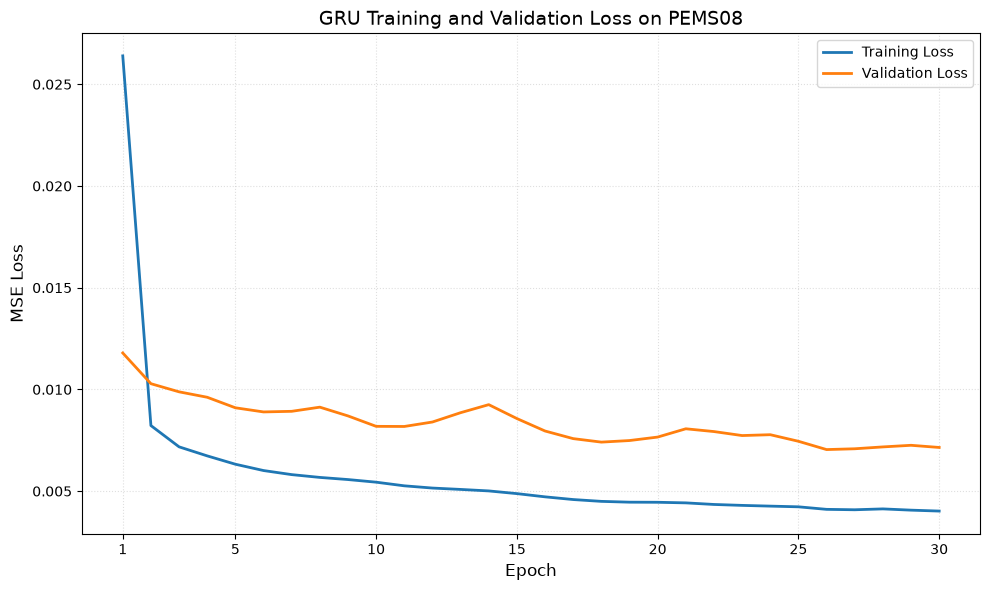

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_losses,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)

plt.title(
    "GRU Training and Validation Loss on PEMS08",
    fontsize=14
)

plt.xticks([1, 5, 10, 15, 20, 25, 30])

plt.grid(
    True,
    linestyle=":",
    alpha=0.4
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "GRU-PEMS08-validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()